# Car Price Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

## Load the data

In [2]:
df = pd.read_csv('car_data.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Renault Kwid,2014,339705,68195.0,petrol,Individual,Manual,First Owner
1,Mahindra XUV500,2005,127696,267893.0,Petrol,Trustmark Dealer,Manual,First Owner
2,Tata Nexon,2016,507312,41874.0,Diesel,Trustmark Dealer,Manual,First Owner
3,Hyundai i20,2005,60731,110533.0,Petrol,Individual,Manual,Second Owner
4,Renault Kwid,2010,207544,53736.0,Petrol,Trustmark Dealer,Manual,First Owner


In [3]:
df.shape

(505, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           505 non-null    str    
 1   year           505 non-null    int64  
 2   selling_price  505 non-null    int64  
 3   km_driven      499 non-null    float64
 4   fuel           505 non-null    str    
 5   seller_type    505 non-null    str    
 6   transmission   505 non-null    str    
 7   owner          505 non-null    str    
dtypes: float64(1), int64(2), str(5)
memory usage: 31.7 KB


## Data cleaning

In [5]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        6
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [6]:
df['km_driven'] = df['km_driven'].fillna(df['km_driven'].median())
df = df.drop_duplicates()
df.shape

(500, 8)

In [7]:
df['fuel'].unique()

<StringArray>
['petrol', 'Petrol', 'Diesel', 'diesel', 'cng', 'CNG', 'LPG', 'lpg']
Length: 8, dtype: str

In [8]:
df['fuel'] = df['fuel'].str.strip().str.capitalize()
df['fuel'].unique()

<StringArray>
['Petrol', 'Diesel', 'Cng', 'Lpg']
Length: 4, dtype: str

## Feature engineering

In [9]:
df['car_age'] = 2021 - df['year']
df['brand'] = df['name'].apply(lambda x: x.split()[0])
df[['name','brand','car_age']].head()

,name,brand,car_age
0,Renault Kwid,Renault,7
1,Mahindra XUV500,Mahindra,16
2,Tata Nexon,Tata,5
3,Hyundai i20,Hyundai,16
4,Renault Kwid,Renault,11


## EDA

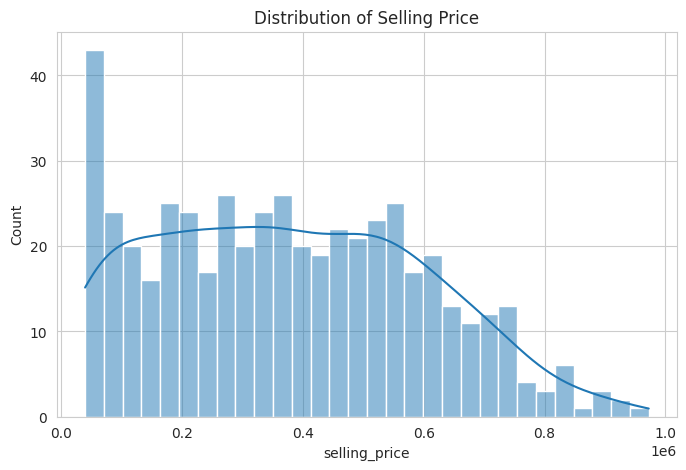

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['selling_price'], bins=30, kde=True)
plt.title('Distribution of Selling Price')
plt.show()

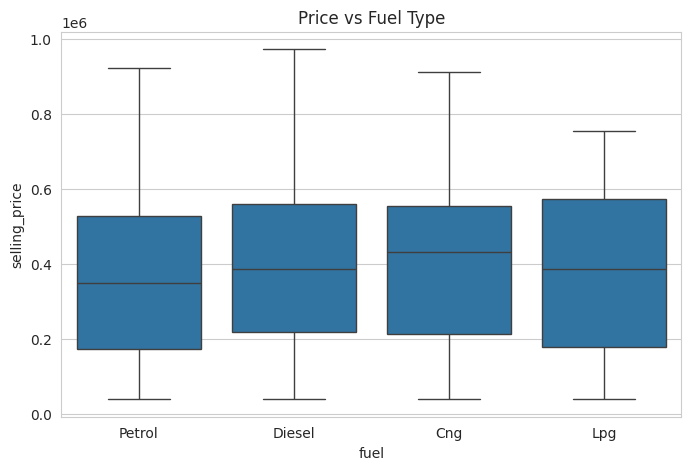

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fuel', y='selling_price', data=df)
plt.title('Price vs Fuel Type')
plt.show()

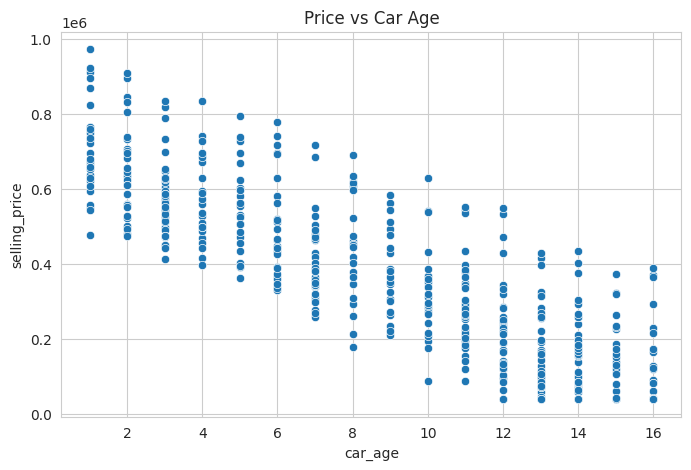

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='car_age', y='selling_price', data=df)
plt.title('Price vs Car Age')
plt.show()

Price clearly goes down as the car gets older, which makes sense. Diesel cars also seem to sell for a bit more on average than petrol ones.

## Encoding categorical variables

In [13]:
df_encoded = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand'], drop_first=True)
df_encoded = df_encoded.drop(columns=['name', 'year'])
df_encoded.head()

,selling_price,km_driven,car_age,fuel_Diesel,fuel_Lpg,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Third Owner,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Renault,brand_Tata,brand_Toyota
0,339705,68195.0,7,False,False,True,True,False,True,False,False,False,False,False,False,False,True,False,False
1,127696,267893.0,16,False,False,True,False,True,True,False,False,False,False,False,True,False,False,False,False
2,507312,41874.0,5,True,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False
3,60731,110533.0,16,False,False,True,True,False,True,False,True,False,False,True,False,False,False,False,False
4,207544,53736.0,11,False,False,True,False,True,True,False,False,False,False,False,False,False,True,False,False


## Correlation heatmap

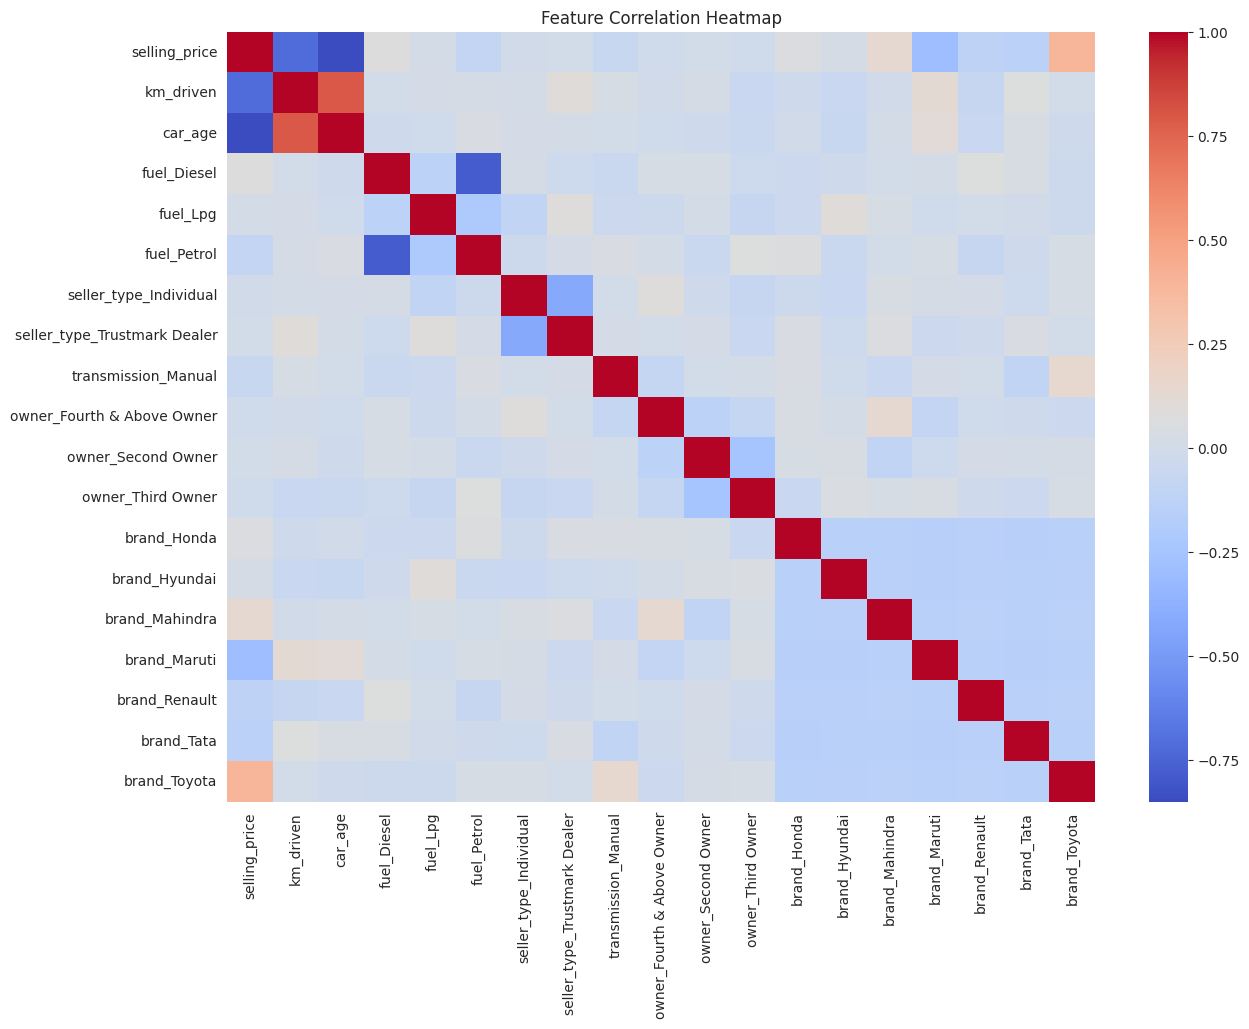

In [14]:
plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

## Train/test split

In [15]:
X = df_encoded.drop(columns=['selling_price'])
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((400, 18), (100, 18))

## Train models

In [16]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_pred = lin_reg.predict(X_test)

In [17]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
rf_pred = rf_reg.predict(X_test)

## Evaluation

In [18]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.3f}')

evaluate(y_test, lin_pred, 'Linear Regression')
evaluate(y_test, rf_pred, 'Random Forest')

Linear Regression -> MAE: 30926.16, RMSE: 38675.21, R2: 0.968
Random Forest -> MAE: 43761.13, RMSE: 57938.72, R2: 0.929


Random Forest performed better than plain Linear Regression on this data, with a higher R2 score and lower error. I'll go with Random Forest as the final model.

## Feature importance (Random Forest)

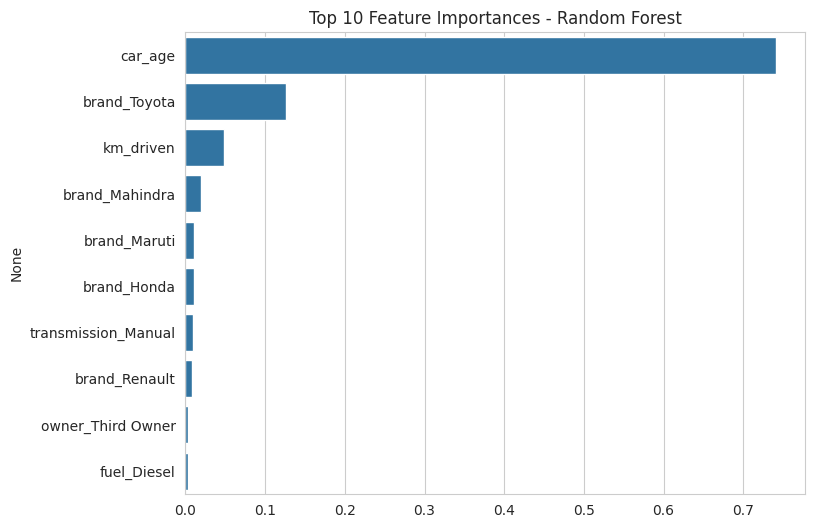

In [19]:
importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 10 Feature Importances - Random Forest')
plt.show()

Car age and km driven turned out to be the biggest factors in predicting price, which lines up with what the scatter plots showed earlier.